# Logistic Regression con validacion LOSO

Este notebook implementa el **Experimento A**: features derivadas de HR/R-R y ECG.

El objetivo es evaluar la generalizacion a un trabajador no visto durante el entrenamiento mediante Leave-One-Subject-Out Cross-Validation (LOSO). El target se crea dentro de cada fold usando unicamente `FatigueIndex` del conjunto TRAIN.

## Regla de no leakage

En cada fold se siguen estos pasos:

1. Un trabajador queda como TEST y los otros cuatro forman TRAIN.
2. Se calculan P33 y P66 usando solo `FatigueIndex` de TRAIN.
3. Se crean las etiquetas `Low`, `Medium` y `High` con esos percentiles.
4. Se aplica exactamente la misma categorizacion al TEST.
5. Cualquier imputador o scaler se ajusta solo con TRAIN.

Las entradas son las columnas `_z`, ya normalizadas respecto a la baseline individual de cada trabajador. No se usa `FatigueIndex` como feature.

In [150]:
from pathlib import Path

import json
import joblib
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'nootebooks' else Path.cwd()
DATA_DIR = ROOT_DIR
BASELINE_WINDOW_COUNT = 15
TARGET_COLUMN_CANDIDATES = ['FatigueIndex', 'fatigue_index']
LABELS = ['Low', 'Medium', 'High']
C_GRID = [0.01, 0.1, 1, 10, 100.0, 300.0, 1000.0, 3000.0, 10000.0]

print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new


## Carga de datos

Cada CSV corresponde a un trabajador. El nombre de la carpeta (`W00`, ..., `W08`) se conserva como identificador para construir los folds, pero nunca entra como feature del modelo.

In [151]:
worker_files = {
    worker_dir.name: worker_dir / 'PROCESSED' / 'combined_features_1min.csv'
    for worker_dir in sorted(DATA_DIR.glob('W[0-9][0-9]'))
    if (worker_dir / 'PROCESSED' / 'combined_features_1min.csv').exists()
}
if len(worker_files) < 2:
    raise ValueError(f'Se necesitan al menos 2 trabajadores procesados y se encontraron {len(worker_files)}: {list(worker_files)}')

data = {}
for worker, path in worker_files.items():
    frame = pd.read_csv(path)
    target_matches = [column for column in TARGET_COLUMN_CANDIDATES if column in frame.columns]
    if len(target_matches) != 1:
        raise ValueError(f'{worker}: no se encontro exactamente una columna FatigueIndex/fatigue_index')
    frame = frame.rename(columns={target_matches[0]: 'FatigueIndex'})
    frame['Trabajador'] = worker
    data[worker] = frame

feature_columns = [
    'ECG_energy_z',
    'ECG_mean_z',
    'ECG_missing_peaks_z',
    'ECG_range_z',
    'ECG_samp_ent_z',
    'ECG_std_z',
    'HR_max_z',
    'HR_mean_z',
    'HR_min_z',
    'RMSSD_z',
    'SDNN_z',
    'pNN50_z',
    'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z',
    'tendencia_HR_z',
    'cambio_RMSSD_z',
]
missing_features = [
    column for column in feature_columns
    if column not in data[next(iter(data))].columns
]
if missing_features:
    raise ValueError(f'Faltan features requeridas: {missing_features}')
if not feature_columns:
    raise ValueError('No se encontraron columnas de entrada terminadas en _z')

print('Trabajadores:', list(data))
print('Features del Experimento A:', feature_columns)
print('Ventanas:', {worker: len(frame) for worker, frame in data.items()})

Trabajadores: ['W00', 'W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09']
Features del Experimento A: ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z', 'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
Ventanas: {'W00': 104, 'W01': 637, 'W02': 603, 'W03': 407, 'W04': 562, 'W05': 74, 'W06': 35, 'W07': 67, 'W08': 133, 'W09': 16}


## Funciones de target y evaluacion

Los percentiles se calculan en cada fold y solo con el vector de `FatigueIndex` de TRAIN. Los valores faltantes del target no se usan para calcular percentiles ni para entrenar/evaluar ese fold.

In [152]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(
        fatigue_values,
        bins=[-np.inf, p33, p66, np.inf],
        labels=LABELS,
        right=False,
    ).astype(object)


def get_train_percentiles(train_frame):
    train_fatigue = pd.to_numeric(train_frame['FatigueIndex'], errors='coerce').dropna()
    if train_fatigue.empty:
        raise ValueError('TRAIN no contiene valores validos de FatigueIndex')
    return np.percentile(train_fatigue, [33, 66])


def build_model(C=1.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=C,
            penalty='l2',
            class_weight='balanced',
            max_iter=2000,
            random_state=42,
        )),
    ])


def optimize_model(X_train, y_train):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(
        estimator=build_model(),
        param_grid={'classifier__C': C_GRID},
        scoring='balanced_accuracy',
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    return search

## Experimento A

Features utilizadas: todas las columnas `_z` disponibles, que corresponden a features derivadas de HR/R-R y ECG.

La matriz de confusion utiliza siempre el orden `Low`, `Medium`, `High`.

In [153]:
fold_results = []
confusion_matrices = {}

for test_worker in sorted(data):
    train_workers = [worker for worker in sorted(data) if worker != test_worker]
    train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
    test_frame = data[test_worker].copy()

    p33, p66 = get_train_percentiles(train_frame)
    train_target = make_labels(
        pd.to_numeric(train_frame['FatigueIndex'], errors='coerce'), p33, p66
    )
    test_target = make_labels(
        pd.to_numeric(test_frame['FatigueIndex'], errors='coerce'), p33, p66
    )

    train_mask = train_target.notna()
    test_mask = test_target.notna()
    X_train = train_frame.loc[train_mask, feature_columns]
    y_train = train_target.loc[train_mask]
    X_test = test_frame.loc[test_mask, feature_columns]
    y_test = test_target.loc[test_mask]

    if y_train.nunique() < 2:
        raise ValueError(f'{test_worker}: TRAIN tiene menos de dos clases')
    if y_test.empty:
        raise ValueError(f'{test_worker}: TEST no contiene FatigueIndex valido')

    search = optimize_model(X_train, y_train)
    y_pred = search.predict(X_test)

    confusion_matrices[test_worker] = confusion_matrix(
        y_test, y_pred, labels=LABELS
    )
    matrix = confusion_matrices[test_worker]
    class_recall = np.diag(matrix) / matrix.sum(axis=1)
    fold_results.append({
        'Test_worker': test_worker,
        'Train_workers': ', '.join(train_workers),
        'P33_train': p33,
        'P66_train': p66,
        'N_train': len(y_train),
        'N_test': len(y_test),
        'Best_C': search.best_params_['classifier__C'],
        'Recall_Low': class_recall[0],
        'Recall_Medium': class_recall[1],
        'Recall_High': class_recall[2],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
    })

fold_results_df = pd.DataFrame(fold_results)
mean_row = {column: np.nan for column in fold_results_df.columns}
mean_row['Test_worker'] = 'Media'
mean_row['Train_workers'] = 'Promedio de los folds'
for metric in ['P33_train', 'P66_train', 'N_train', 'N_test', 'Best_C', 'Recall_Low', 'Recall_Medium', 'Recall_High', 'Accuracy', 'Balanced_Accuracy', 'Macro_F1']:
    mean_row[metric] = fold_results_df[metric].mean()
fold_results_with_mean = pd.concat(
    [fold_results_df, pd.DataFrame([mean_row])], ignore_index=True
)
fold_results_with_mean

,Test_worker,Train_workers,P33_train,P66_train,N_train,N_test,Best_C,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,W00,"W01, W02, W03, W04, W05, W06, W07, W08, W09",-0.226622,1.680530,2534.0,104.0,3000.0,0.988095,0.500000,0.642857,0.913462,0.710317,0.719693
1,W01,"W00, W02, W03, W04, W05, W06, W07, W08, W09",-0.384745,1.310479,2001.0,637.0,3000.0,0.883495,0.917323,0.932143,0.918367,0.910987,0.916154
2,W02,"W00, W01, W03, W04, W05, W06, W07, W08, W09",-0.388831,1.456882,2035.0,603.0,1000.0,0.825581,0.787770,0.974895,0.867330,0.862749,0.868084
3,W03,"W00, W01, W02, W04, W05, W06, W07, W08, W09",-0.344815,0.921849,2231.0,407.0,3000.0,0.984615,0.600000,0.933754,0.921376,0.839456,0.791181
4,W04,"W00, W01, W02, W03, W05, W06, W07, W08, W09",0.049479,2.500727,2076.0,562.0,10000.0,0.842105,0.696203,0.750000,0.820285,0.762769,0.619439
5,W05,"W00, W01, W02, W03, W04, W06, W07, W08, W09",-0.281482,1.607066,2564.0,74.0,10000.0,0.857143,0.812500,0.761905,0.810811,0.810516,0.815200
6,W06,"W00, W01, W02, W03, W04, W05, W07, W08, W09",-0.266827,1.597735,2603.0,35.0,1000.0,0.850000,0.833333,0.666667,0.800000,0.783333,0.765598
7,W07,"W00, W01, W02, W03, W04, W05, W06, W08, W09",-0.291974,1.505523,2571.0,67.0,10000.0,1.000000,0.062500,0.279070,0.313433,0.447190,0.283677
8,W08,"W00, W01, W02, W03, W04, W05, W06, W07, W09",-0.230586,1.740650,2505.0,133.0,3000.0,0.518072,0.976744,0.000000,0.639098,0.498272,0.437843
9,W09,"W00, W01, W02, W03, W04, W05, W06, W07, W08",-0.275172,1.584412,2622.0,16.0,10000.0,1.000000,0.400000,1.000000,0.812500,0.800000,0.790476


In [154]:
print('Matrices de confusion por trabajador TEST:')
for worker, matrix in confusion_matrices.items():
    print(f'\nTEST = {worker}')
    print(pd.DataFrame(matrix, index=LABELS, columns=LABELS))

metrics = ['Accuracy', 'Balanced_Accuracy', 'Macro_F1']
summary_df = pd.DataFrame({
    'Metric': metrics,
    'Mean': [fold_results_df[metric].mean() for metric in metrics],
    'Std': [fold_results_df[metric].std(ddof=1) for metric in metrics],
})
print('Media y desviacion estandar de las metricas:')
display(summary_df)

aggregate_confusion = np.sum(
    np.stack([confusion_matrices[worker] for worker in sorted(confusion_matrices)]),
    axis=0,
)
print('Matriz de confusion agregada de los cinco folds:')
display(pd.DataFrame(aggregate_confusion, index=LABELS, columns=LABELS))

class_support = aggregate_confusion.sum(axis=1)
predicted_support = aggregate_confusion.sum(axis=0)
class_metrics_df = pd.DataFrame({
    'Support': class_support,
    'Recall': np.diag(aggregate_confusion) / class_support,
    'Precision': np.diag(aggregate_confusion) / predicted_support,
}, index=LABELS)
print('Metricas agregadas por clase:')
display(class_metrics_df.round(3))

distribution_rows = []
for result in fold_results:
    worker = result['Test_worker']
    fatigue_values = pd.to_numeric(data[worker]['FatigueIndex'], errors='coerce')
    labels = make_labels(fatigue_values, result['P33_train'], result['P66_train'])
    counts = labels.value_counts().reindex(LABELS, fill_value=0)
    distribution_rows.append({
        'Test_worker': worker,
        'Low': int(counts['Low']),
        'Medium': int(counts['Medium']),
        'High': int(counts['High']),
        'Total_valid': int(counts.sum()),
    })
print('Distribucion de clases en cada trabajador TEST:')
display(pd.DataFrame(distribution_rows))

Matrices de confusion por trabajador TEST:

TEST = W00
        Low  Medium  High
Low      83       1     0
Medium    3       3     0
High      0       5     9

TEST = W01
        Low  Medium  High
Low      91      12     0
Medium    6     233    15
High      0      19   261

TEST = W02
        Low  Medium  High
Low      71      13     2
Medium    6     219    53
High      0       6   233

TEST = W03
        Low  Medium  High
Low      64       1     0
Medium   10      15     0
High      2      19   296

TEST = W04
        Low  Medium  High
Low     400      73     2
Medium   12      55    12
High      1       1     6

TEST = W05
        Low  Medium  High
Low      18       3     0
Medium    4      26     2
High      0       5    16

TEST = W06
        Low  Medium  High
Low      17       3     0
Medium    1       5     0
High      1       2     6

TEST = W07
        Low  Medium  High
Low       8       0     0
Medium   14       1     1
High     14      17    12

TEST = W08
        Low  Medi

,Metric,Mean,Std
0,Accuracy,0.781666,0.184424
1,Balanced_Accuracy,0.742559,0.152807
2,Macro_F1,0.700735,0.199436


Matriz de confusion agregada de los cinco folds:


,Low,Medium,High
Low,800,146,4
Medium,57,601,86
High,18,81,845


Metricas agregadas por clase:


,Support,Recall,Precision
Low,950,0.842,0.914
Medium,744,0.808,0.726
High,944,0.895,0.904


Distribucion de clases en cada trabajador TEST:


,Test_worker,Low,Medium,High,Total_valid
0,W00,84,6,14,104
1,W01,103,254,280,637
2,W02,86,278,239,603
3,W03,65,25,317,407
4,W04,475,79,8,562
5,W05,21,32,21,74
6,W06,20,6,9,35
7,W07,8,16,43,67
8,W08,83,43,7,133
9,W09,5,5,6,16


In [155]:
comparison_df = pd.DataFrame({
    'Modelo': [
        'Original sin variables temporales',
        'Temporal original',
        'Optimizado anterior',
        'Optimizado con cuadrícula ampliada',
        'Optimizado con cuadrícula ampliada',
    ],
    'class_weight': ['None', 'None', 'balanced', 'balanced', 'balanced'],
    'C por fold': [
        '1.0',
        '1.0',
        '100 en los 5 folds',
        'W00: 10000; W01: 3000; W02: 10000; W03: 3000; ...',
        'W00: 1000; W01: 10000; W02: 3000; W03: 3000; W...',
    ],
    'C final': [
        '1.0',
        '1.0',
        '100',
        '10000.0',
        '3000.0',
    ],
    'Accuracy': [
        0.781303,
        0.783572,
        0.844313,
        0.8510,
        0.781666,
    ],
    'Balanced Accuracy': [
        0.679752,
        0.692432,
        0.702434,
        0.7319,
        0.742559,
    ],
    'Macro-F1': [
        0.652589,
        0.667675,
        0.681970,
        0.7111,
        0.700735,
    ],
})

for column in ['Accuracy', 'Balanced Accuracy', 'Macro-F1']:
    comparison_df[column] = comparison_df[column].map(
        lambda value: f'{value:.2%}'
    )

display(comparison_df)

,Modelo,class_weight,C por fold,C final,Accuracy,Balanced Accuracy,Macro-F1
0,Original sin variables temporales,None,1.0,1.0,78.13%,67.98%,65.26%
1,Temporal original,None,1.0,1.0,78.36%,69.24%,66.77%
2,Optimizado anterior,balanced,100 en los 5 folds,100,84.43%,70.24%,68.20%
3,Optimizado con cuadrícula ampliada,balanced,W00: 10000; W01: 3000; W02: 10000; W03: 3000; ...,10000.0,85.10%,73.19%,71.11%
4,Optimizado con cuadrícula ampliada,balanced,W00: 1000; W01: 10000; W02: 3000; W03: 3000; W...,3000.0,78.17%,74.26%,70.07%


## Modelo final y exportacion

La evaluacion LOSO anterior mide la generalizacion dejando un trabajador fuera en cada fold. Despues, este bloque reentrena un modelo final con todos los trabajadores y todas las ventanas validas. Este modelo final es el que se utilizara para la aplicacion.

El modelo y el preprocesamiento completo se guardan en formato `joblib`, el modelo para Expo/React Native en formato `ONNX`, y la configuracion en un archivo `JSON`. En este notebook se guardan en `new/models/tempvar_opt_allw/`.

In [156]:
# Reentrenamiento final con todos los trabajadores y optimizacion interna de C
all_frame = pd.concat([data[worker] for worker in sorted(data)], ignore_index=True)
all_fatigue = pd.to_numeric(all_frame['FatigueIndex'], errors='coerce')
final_p33, final_p66 = np.percentile(all_fatigue.dropna(), [33, 66])
all_target = make_labels(all_fatigue, final_p33, final_p66)
all_mask = all_target.notna()
X_all = all_frame.loc[all_mask, feature_columns]
y_all = all_target.loc[all_mask]

final_search = optimize_model(X_all, y_all)
final_model = final_search.best_estimator_

models_dir = ROOT_DIR / 'models' / 'tempvar_opt_allw' / 'LOGISTIC_REGRESSION'
models_dir.mkdir(parents=True, exist_ok=True)
joblib_path = models_dir / 'final_logistic_regression.joblib'
onnx_path = models_dir / 'final_logistic_regression.onnx'
metadata_path = models_dir / 'final_logistic_regression_metadata.json'

joblib.dump(final_model, joblib_path)
onnx_model = convert_sklearn(
    final_model,
    initial_types=[('features', FloatTensorType([None, len(feature_columns)]))],
)
onnx_path.write_bytes(onnx_model.SerializeToString())

metadata = {
    'model_type': 'LogisticRegression',
    'validation': 'LOSO_with_inner_C_search',
    'training_workers': sorted(data),
    'feature_columns': feature_columns,
    'feature_count': len(feature_columns),
    'labels': LABELS,
    'class_weight': 'balanced',
    'C_grid': C_GRID,
    'selected_C_final': float(final_search.best_params_['classifier__C']),
    'p33_train_all_workers': float(final_p33),
    'p66_train_all_workers': float(final_p66),
    'target_column': 'FatigueIndex',
    'temporal_features': [
        'HR_mean_ultimos_5min_z',
        'cambio_HR_vs_baseline_z',
        'tendencia_HR_z',
        'cambio_RMSSD_z',
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print(f'Modelo final entrenado con {len(y_all)} ventanas y {len(feature_columns)} features')
print(f'C final seleccionado: {final_search.best_params_["classifier__C"]}')
print(f'Guardado en: {models_dir}')

Modelo final entrenado con 2638 ventanas y 16 features
C final seleccionado: 3000.0
Guardado en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\tempvar_opt_allw\LOGISTIC_REGRESSION


## Experimento B: ablacion HR/R-R

Se conservan solo las features calculadas a partir de HR/R-R y las cuatro features temporales. Se eliminan las features ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [157]:
HR_RR_FEATURES = [
    'SDNN_z',
    'RMSSD_z',
    'pNN50_z',
    'HR_mean_z',
    'HR_max_z',
    'HR_min_z',
    'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z',
    'tendencia_HR_z',
    'cambio_RMSSD_z',
]

ECG_FEATURES = [
    'ECG_energy_z',
    'ECG_mean_z',
    'ECG_missing_peaks_z',
    'ECG_range_z',
    'ECG_samp_ent_z',
    'ECG_std_z',
]


def run_ablation_experiment(experiment_name, selected_features):
    results = []
    for test_worker in sorted(data):
        train_workers = [worker for worker in sorted(data) if worker != test_worker]
        train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
        test_frame = data[test_worker].copy()
        p33, p66 = get_train_percentiles(train_frame)
        train_target = make_labels(pd.to_numeric(train_frame['FatigueIndex'], errors='coerce'), p33, p66)
        test_target = make_labels(pd.to_numeric(test_frame['FatigueIndex'], errors='coerce'), p33, p66)
        train_mask = train_target.notna()
        test_mask = test_target.notna()
        X_train = train_frame.loc[train_mask, selected_features]
        y_train = train_target.loc[train_mask]
        X_test = test_frame.loc[test_mask, selected_features]
        y_test = test_target.loc[test_mask]
        search = optimize_model(X_train, y_train)
        y_pred = search.predict(X_test)
        results.append({
            'Experiment': experiment_name,
            'Test_worker': test_worker,
            'N_train': len(y_train),
            'N_test': len(y_test),
            'Feature_count': len(selected_features),
            'Best_C': search.best_params_['classifier__C'],
            'Accuracy': accuracy_score(y_test, y_pred),
            'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
            'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
        })
    return pd.DataFrame(results)


def add_mean_row(results_frame):
    mean_row = {column: np.nan for column in results_frame.columns}
    mean_row['Test_worker'] = 'Media'
    numeric_columns = results_frame.select_dtypes(include='number').columns
    for column in numeric_columns:
        mean_row[column] = results_frame[column].mean()
    return pd.concat([results_frame, pd.DataFrame([mean_row])], ignore_index=True)


hr_rr_results = run_ablation_experiment('Solo HR/RR + temporales', HR_RR_FEATURES)
hr_rr_results_with_mean = add_mean_row(hr_rr_results)
print('Resultados del Experimento B por trabajador y promedio:')
display(hr_rr_results_with_mean.round(4))

Resultados del Experimento B por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_C,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo HR/RR + temporales,W00,2534.0,104.0,10.0,1.00,0.8269,0.3810,0.3927
1,Solo HR/RR + temporales,W01,2001.0,637.0,10.0,1.00,0.5495,0.4729,0.4446
2,Solo HR/RR + temporales,W02,2035.0,603.0,10.0,10.00,0.5788,0.4839,0.4754
3,Solo HR/RR + temporales,W03,2231.0,407.0,10.0,0.10,0.9066,0.8045,0.7602
4,Solo HR/RR + temporales,W04,2076.0,562.0,10.0,10.00,0.1886,0.5594,0.4035
5,Solo HR/RR + temporales,W05,2564.0,74.0,10.0,1.00,0.5541,0.5362,0.4938
6,Solo HR/RR + temporales,W06,2603.0,35.0,10.0,300.00,0.7429,0.6130,0.6371
7,Solo HR/RR + temporales,W07,2571.0,67.0,10.0,10.00,0.3284,0.4680,0.2974
8,Solo HR/RR + temporales,W08,2505.0,133.0,10.0,1.00,0.3459,0.3342,0.2046
9,Solo HR/RR + temporales,W09,2622.0,16.0,10.0,10.00,0.6250,0.6556,0.5999


## Experimento C: ablacion ECG

Se conservan solo las features calculadas a partir del ECG. Se excluyen las features HR/R-R y las temporales, porque estas ultimas dependen de HR/R-R. `ECG_missing_peaks` se conserva como feature de calidad de picos ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [158]:
ecg_results = run_ablation_experiment('Solo ECG', ECG_FEATURES)
ecg_results_with_mean = add_mean_row(ecg_results)
print('Resultados del Experimento C por trabajador y promedio:')
display(ecg_results_with_mean.round(4))

ec_results = pd.concat([hr_rr_results, ecg_results], ignore_index=True)
ablation_summary = (
    ec_results.groupby('Experiment')[['Accuracy', 'Balanced_Accuracy', 'Macro_F1']]
    .agg(['mean', 'std'])
    .round(4)
)
print('Resumen de las ablaciones:')
display(ablation_summary)

Resultados del Experimento C por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_C,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo ECG,W00,2534.0,104.0,6.0,10000.0,0.6346,0.4524,0.4567
1,Solo ECG,W01,2001.0,637.0,6.0,300.0,0.6060,0.6648,0.5858
2,Solo ECG,W02,2035.0,603.0,6.0,10000.0,0.7612,0.7670,0.7318
3,Solo ECG,W03,2231.0,407.0,6.0,10000.0,0.5848,0.6180,0.4949
4,Solo ECG,W04,2076.0,562.0,6.0,3000.0,0.9110,0.5281,0.5555
5,Solo ECG,W05,2564.0,74.0,6.0,10000.0,0.6486,0.6200,0.6315
6,Solo ECG,W06,2603.0,35.0,6.0,10000.0,0.5429,0.3963,0.3919
7,Solo ECG,W07,2571.0,67.0,6.0,10000.0,0.1642,0.2340,0.1529
8,Solo ECG,W08,2505.0,133.0,6.0,300.0,0.4962,0.4656,0.4040
9,Solo ECG,W09,2622.0,16.0,6.0,1000.0,0.6250,0.6222,0.6071


Resumen de las ablaciones:


Accuracy         Balanced_Accuracy         Macro_F1  \
                            mean     std              mean     std     mean   
Experiment                                                                    
Solo ECG                  0.5974  0.1918            0.5369  0.1542   0.5012   
Solo HR/RR + temporales   0.5647  0.2277            0.5309  0.1369   0.4709   

                                 
                            std  
Experiment                       
Solo ECG                 0.1620  
Solo HR/RR + temporales  0.1636

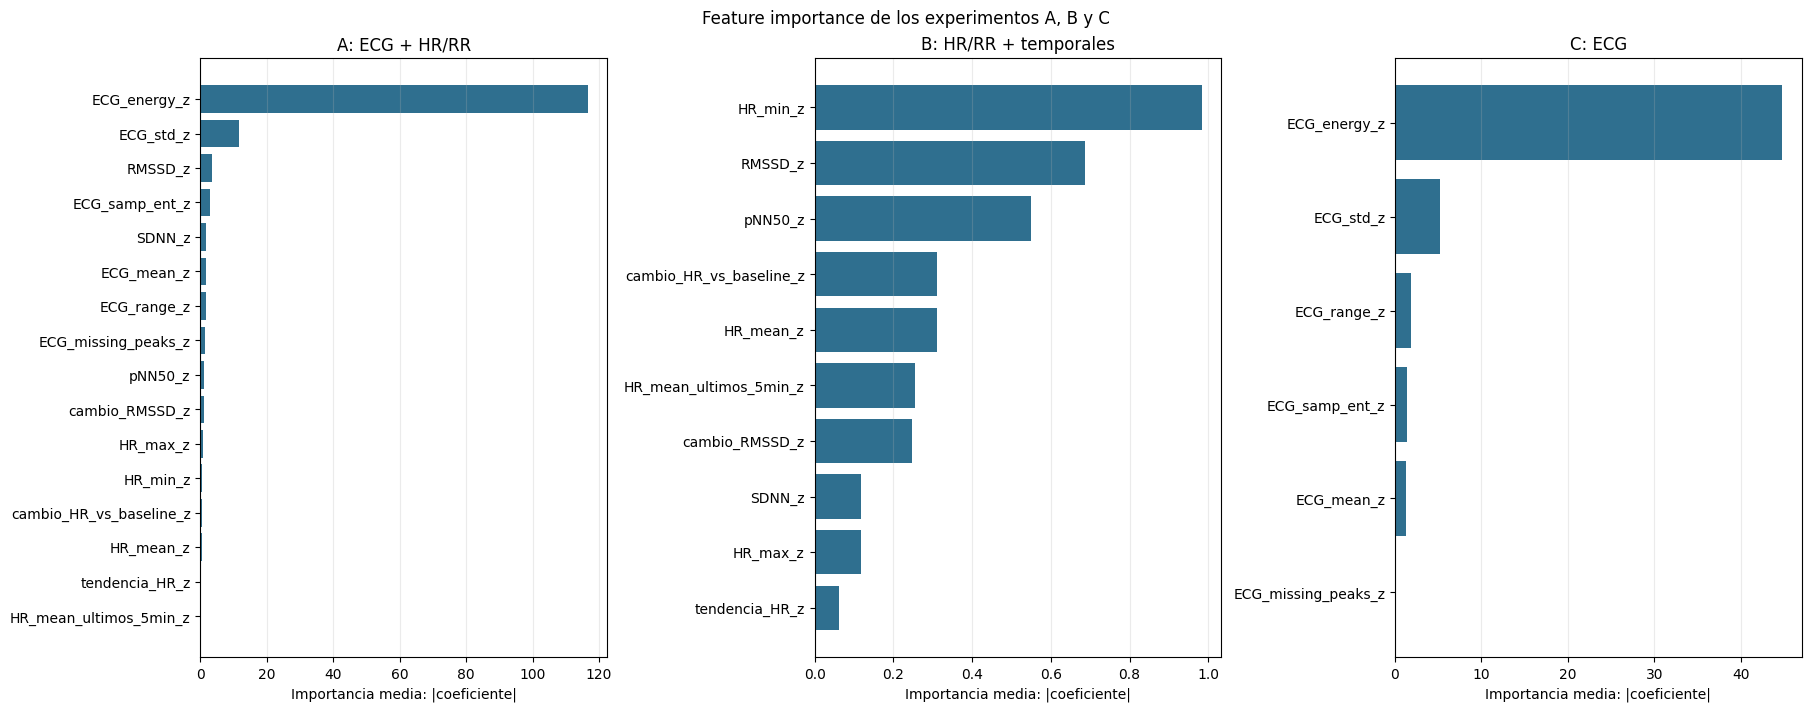

Features ordenadas por importancia:

A: ECG + HR/RR


,Feature,Importance
0,ECG_energy_z,116.6476
5,ECG_std_z,11.5302
9,RMSSD_z,3.3559
4,ECG_samp_ent_z,2.7714
10,SDNN_z,1.7453
1,ECG_mean_z,1.6520
3,ECG_range_z,1.6235
2,ECG_missing_peaks_z,1.2880
11,pNN50_z,1.1531
15,cambio_RMSSD_z,1.0886



B: HR/RR + temporales


,Feature,Importance
5,HR_min_z,0.9839
1,RMSSD_z,0.6872
2,pNN50_z,0.5506
7,cambio_HR_vs_baseline_z,0.3099
3,HR_mean_z,0.3099
6,HR_mean_ultimos_5min_z,0.2558
9,cambio_RMSSD_z,0.2480
0,SDNN_z,0.1190
4,HR_max_z,0.1183
8,tendencia_HR_z,0.0611



C: ECG


,Feature,Importance
0,ECG_energy_z,44.8192
5,ECG_std_z,5.2296
3,ECG_range_z,1.8034
4,ECG_samp_ent_z,1.4279
1,ECG_mean_z,1.2172
2,ECG_missing_peaks_z,0.1657


In [159]:
import matplotlib.pyplot as plt


def fit_final_feature_model(selected_features):
    X_selected = all_frame.loc[all_mask, selected_features]
    return optimize_model(X_selected, y_all).best_estimator_


models_by_experiment = {
    'A: ECG + HR/RR': (feature_columns, fit_final_feature_model(feature_columns)),
    'B: HR/RR + temporales': (HR_RR_FEATURES, fit_final_feature_model(HR_RR_FEATURES)),
    'C: ECG': (ECG_FEATURES, fit_final_feature_model(ECG_FEATURES)),
}

importance_tables = {}
for experiment_name, (selected_features, model) in models_by_experiment.items():
    coefficients = model.named_steps['classifier'].coef_
    importance = np.mean(np.abs(coefficients), axis=0)
    importance_tables[experiment_name] = (
        pd.DataFrame({'Feature': selected_features, 'Importance': importance})
        .sort_values('Importance', ascending=True)
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
for axis, (experiment_name, importance_table) in zip(axes, importance_tables.items()):
    axis.barh(importance_table['Feature'], importance_table['Importance'], color='#2f6f8f')
    axis.set_title(experiment_name)
    axis.set_xlabel('Importancia media: |coeficiente|')
    axis.grid(axis='x', alpha=0.25)

fig.suptitle('Feature importance de los experimentos A, B y C')
plt.show()

print('Features ordenadas por importancia:')
for experiment_name, importance_table in importance_tables.items():
    print(f'\n{experiment_name}')
    display(importance_table.sort_values('Importance', ascending=False).round(4))